1. ПОДГОТОВКА ВРЕМЕННОГО РЯДА

1.1 Проверка полноты данных:
Количество записей: 36
Период: с 2021-01-31 по 2023-12-31
Пропуски в данных: 0
Дубликаты: 0

1.2 Проверка сезонности:
Средние значения по месяцам:
  Месяц  1:  118169.77
  Месяц  2:  128055.67
  Месяц  3:  134768.96
  Месяц  4:  135622.05
  Месяц  5:  131869.34
  Месяц  6:  135690.18
  Месяц  7:  132286.29
  Месяц  8:  129746.96
  Месяц  9:  126598.54
  Месяц 10:  124570.89
  Месяц 11:  126713.22
  Месяц 12:  134415.95


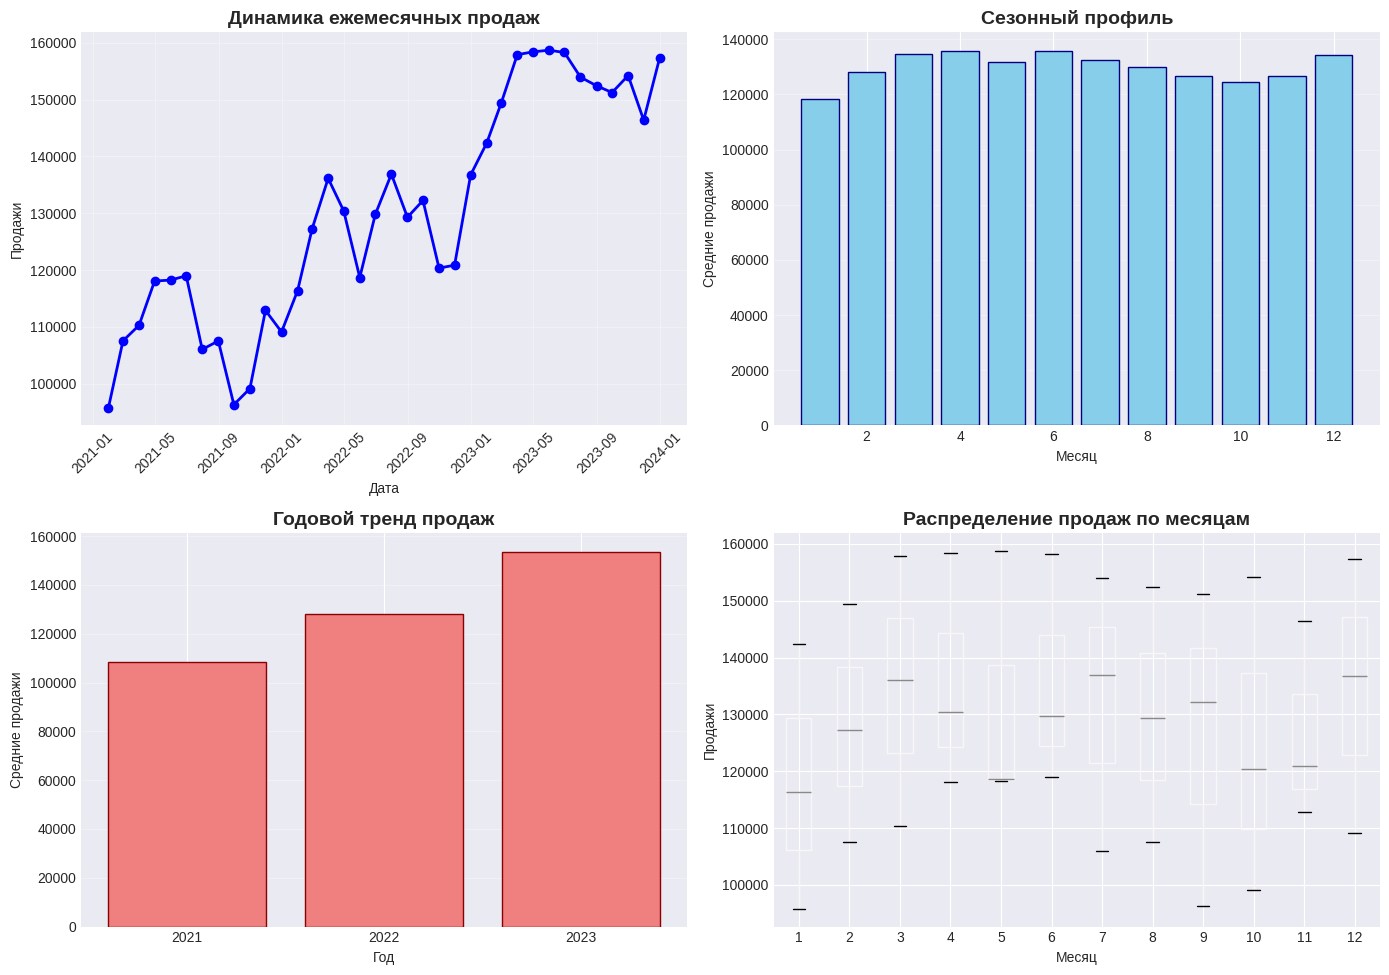

✓ График 1 сохранен как 'plot1_dynamics.png'

1.3 Создание дополнительных признаков...
Создано признаков: время, сезонность, скользящее среднее, темп роста, кварталы

2. РЕАЛИЗАЦИЯ МОДЕЛЕЙ

Обучающая выборка: 30 месяцев
Тестовая выборка: 6 месяцев

2.1 Линейная регрессия (с доп. признаками)
Коэффициенты модели:
  time_index: 377.03
  month_sin: 3470.51
  month_cos: 1506.61
  ma_3: 0.83
  quarter: -395.19
  high_season: -34.32
  low_season: -4221.38
  intercept: 19110.72

2.2 Полиномиальная регрессия (степень=2)
R² на обучении: 0.7925

2.3 Экспоненциальное сглаживание
Параметр сглаживания (alpha): 1.0000

3. ОЦЕНКА ТОЧНОСТИ МОДЕЛЕЙ

Сравнение метрик качества прогнозирования:
---------------------------------------------------------------------------
Модель                    MAE          MSE          RMSE         MAPE (%)    
---------------------------------------------------------------------------
Линейная регрессия        3295.37      16662281.22  4081.95      2.19        
Полиномиа

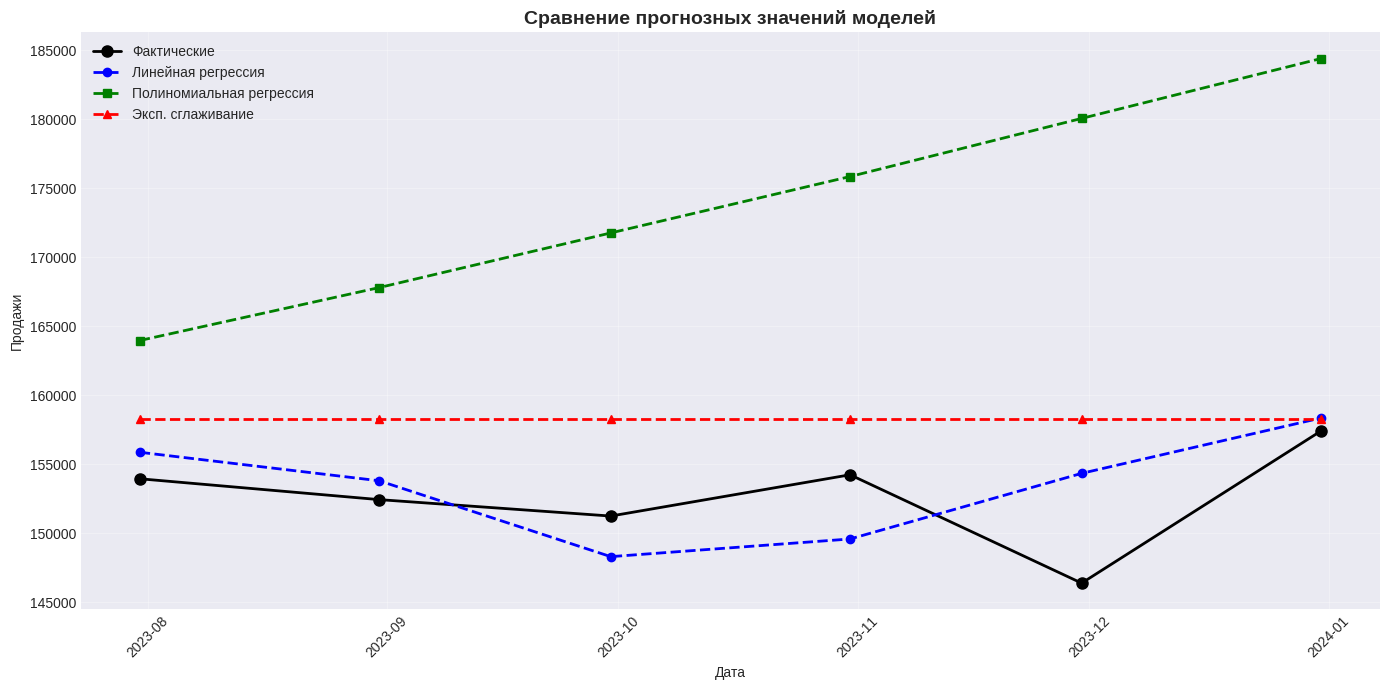

✓ График 2 сохранен как 'plot2_predictions.png'


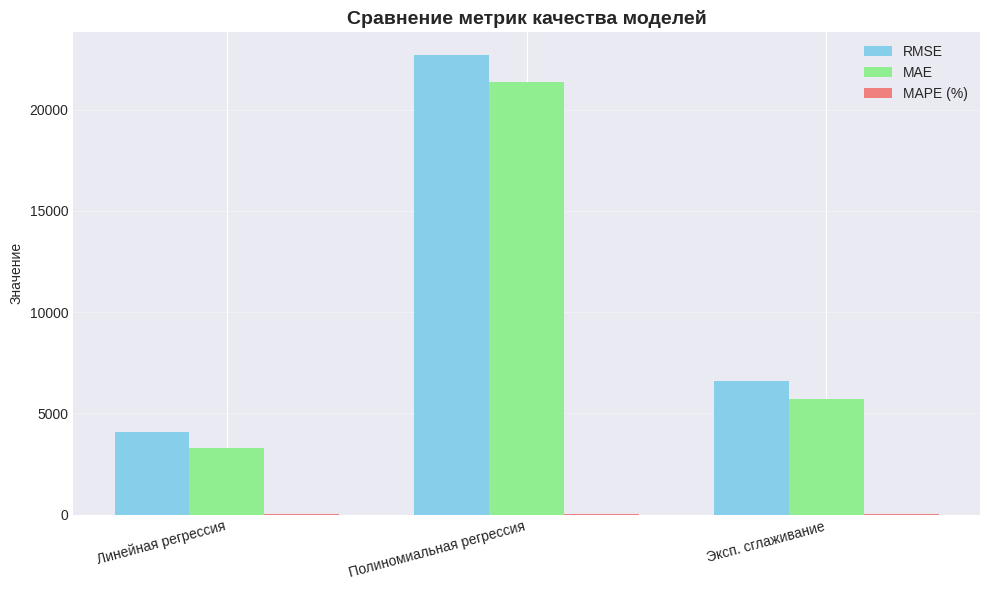

✓ График 3 сохранен как 'plot3_metrics.png'


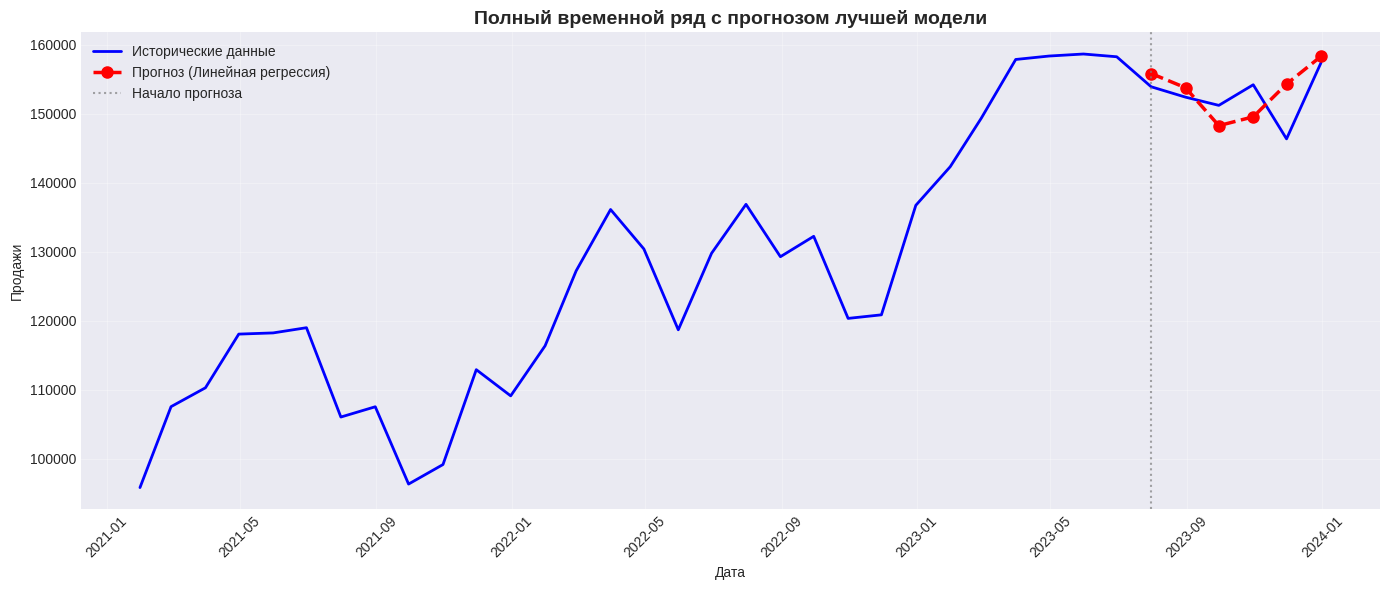

✓ График 4 сохранен как 'plot4_best_model.png'

5. ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ

Прогноз продаж на следующие 6 месяцев (модель Линейная регрессия):
-------------------------------------------------------
Дата            Прогноз продаж       Изменение   
-------------------------------------------------------
2024-01-31           161,439.79       +2.56%
2024-02-29           162,535.66       +0.68%
2024-03-31           162,590.02       +0.03%
2024-04-30           161,353.60       -0.76%
2024-05-31           159,908.88       -0.90%
2024-06-30           158,348.81       -0.98%


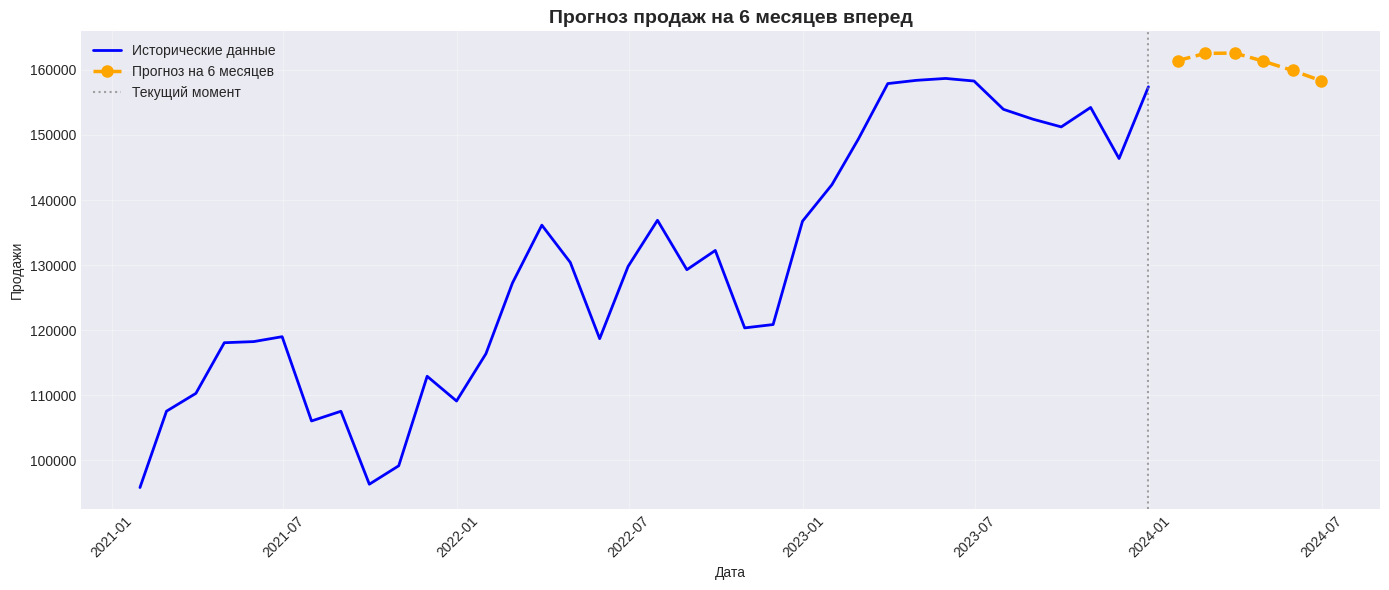

✓ График 5 сохранен как 'plot5_forecast.png'

6. АНАЛИТИЧЕСКИЙ ВЫВОД

1. АНАЛИЗ ВРЕМЕННОГО РЯДА:
   • Данные: 36 месяцев (янв 2021 - дек 2023)
   • Пропусков нет, данные готовы к моделированию
   • Средние продажи: 129,876
   • Рост за период: с 108,326 до 153,385 
     (+41.6%)
   • Сезонность: пик в мае (131,869), спад в сентябре (126,599)

2. СРАВНЕНИЕ МОДЕЛЕЙ:
   • Лучшая модель: Линейная регрессия
   • RMSE: 4081.95
   • MAPE: 2.19%
   
   Результаты всех моделей:
   • Линейная регрессия: MAPE = 2.19%
   • Полиномиальная регрессия: MAPE = 14.05%
   • Экспоненциальное сглаживание: MAPE = 3.78%

3. ПРОГНОЗНЫЕ ЗНАЧЕНИЯ:
   • Средний прогноз: 161,029
   • Прогноз на June 2024: 158,348.81
   • Ожидаемый рост: +0.6%

4. РЕКОМЕНДАЦИИ:
   • Для прогнозирования использовать модель Линейная регрессия
   • Обновлять модель ежемесячно с добавлением новых данных
   • Учитывать сезонность при планировании производства


ГОТОВО! Сохраненные файлы:
  plot1_dynamics.png - Анализ временного ряда
  

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Загрузка данных
data = """date,monthly_sales
2021-01-31,95799.45
2021-02-28,107537.77
2021-03-31,110276.15
2021-04-30,118061.86
2021-05-31,118234.89
2021-06-30,118989.48
2021-07-31,106032.93
2021-08-31,107523.68
2021-09-30,96311.3
2021-10-31,99141.87
2021-11-30,112903.11
2021-12-31,109103.72
2022-01-31,116366.88
2022-02-28,127244.32
2022-03-31,136134.06
2022-04-30,130410.15
2022-05-31,118684.78
2022-06-30,129791.74
2022-07-31,136885.28
2022-08-31,129287.1
2022-09-30,132244.83
2022-10-31,120340.92
2022-11-30,120857.05
2022-12-31,136741.31
2023-01-31,142342.97
2023-02-28,149384.91
2023-03-31,157896.67
2023-04-30,158394.14
2023-05-31,158688.34
2023-06-30,158289.32
2023-07-31,153940.65
2023-08-31,152430.09
2023-09-30,151239.49
2023-10-31,154229.87
2023-11-30,146379.5
2023-12-31,157402.81"""

from io import StringIO
df = pd.read_csv(StringIO(data))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("=" * 80)
print("1. ПОДГОТОВКА ВРЕМЕННОГО РЯДА")
print("=" * 80)

# 1.1 Проверка полноты данных
print(f"\n1.1 Проверка полноты данных:")
print(f"Количество записей: {len(df)}")
print(f"Период: с {df['date'].min().date()} по {df['date'].max().date()}")
print(f"Пропуски в данных: {df['monthly_sales'].isnull().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

# 1.2 Обработка пропусков
if df['monthly_sales'].isnull().sum() > 0:
    df['monthly_sales'] = df['monthly_sales'].interpolate()

# 1.3 Проверка сезонности
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
monthly_avg = df.groupby('month')['monthly_sales'].mean()
yearly_avg = df.groupby('year')['monthly_sales'].mean()

print(f"\n1.2 Проверка сезонности:")
print("Средние значения по месяцам:")
for month in range(1, 13):
    print(f"  Месяц {month:2d}: {monthly_avg[month]:10.2f}")

# 1.4 Построение графика динамики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df['date'], df['monthly_sales'], 'b-o', linewidth=2, markersize=6)
axes[0, 0].set_title('Динамика ежемесячных продаж', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Продажи')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='skyblue', edgecolor='navy')
axes[0, 1].set_title('Сезонный профиль', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Средние продажи')
axes[0, 1].grid(True, alpha=0.3, axis='y')

years = yearly_avg.index.astype(str)
axes[1, 0].bar(years, yearly_avg.values, color='lightcoral', edgecolor='darkred')
axes[1, 0].set_title('Годовой тренд продаж', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Год')
axes[1, 0].set_ylabel('Средние продажи')
axes[1, 0].grid(True, alpha=0.3, axis='y')

df.boxplot(column='monthly_sales', by='month', ax=axes[1, 1])
axes[1, 1].set_title('Распределение продаж по месяцам', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Продажи')
plt.suptitle('')

plt.tight_layout()
plt.savefig('plot1_dynamics.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 1 сохранен как 'plot1_dynamics.png'")

# ==================== УЛУЧШЕННЫЕ ПРИЗНАКИ ====================

print(f"\n1.3 Создание дополнительных признаков...")

# Базовые признаки
df['time_index'] = np.arange(len(df))
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Простые улучшения
df['ma_3'] = df['monthly_sales'].rolling(window=3, min_periods=1).mean()
df['growth'] = df['monthly_sales'].pct_change() * 100
df['growth'] = df['growth'].fillna(0)
df['quarter'] = df['date'].dt.quarter
df['high_season'] = df['month'].isin([3, 4, 5, 6]).astype(int)
df['low_season'] = df['month'].isin([9, 10]).astype(int)

# Удаляем NaN
df = df.fillna(method='bfill')

print(f"Создано признаков: время, сезонность, скользящее среднее, темп роста, кварталы")

# Разделение на обучающую и тестовую выборки
test_size = 6
train_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

print(f"\n" + "=" * 80)
print("2. РЕАЛИЗАЦИЯ МОДЕЛЕЙ")
print("=" * 80)
print(f"\nОбучающая выборка: {len(train_df)} месяцев")
print(f"Тестовая выборка: {len(test_df)} месяцев")

# ==================== МОДЕЛЬ 1: ЛИНЕЙНАЯ РЕГРЕССИЯ ====================

print(f"\n2.1 Линейная регрессия (с доп. признаками)")

features_lr = ['time_index', 'month_sin', 'month_cos', 'ma_3', 'quarter', 'high_season', 'low_season']
X_train_lr = train_df[features_lr]
y_train = train_df['monthly_sales']

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)

X_test_lr = test_df[features_lr]
lr_predictions = lr_model.predict(X_test_lr)

print(f"Коэффициенты модели:")
for feat, coef in zip(features_lr, lr_model.coef_):
    print(f"  {feat}: {coef:.2f}")
print(f"  intercept: {lr_model.intercept_:.2f}")

# ==================== МОДЕЛЬ 2: ПОЛИНОМИАЛЬНАЯ РЕГРЕССИЯ ====================

print(f"\n2.2 Полиномиальная регрессия (степень=2)")

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(train_df[['time_index']])
X_test_poly = poly.transform(test_df[['time_index']])

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
poly_predictions = poly_model.predict(X_test_poly)

print(f"R² на обучении: {poly_model.score(X_train_poly, y_train):.4f}")

# ==================== МОДЕЛЬ 3: ЭКСПОНЕНЦИАЛЬНОЕ СГЛАЖИВАНИЕ ====================

print(f"\n2.3 Экспоненциальное сглаживание")

ts_data = df['monthly_sales'].values
train_ts = ts_data[:-test_size]

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(train_ts)
ses_fit = ses_model.fit()
ses_predictions = ses_fit.forecast(test_size)

print(f"Параметр сглаживания (alpha): {ses_fit.params['smoothing_level']:.4f}")

# ==================== ОЦЕНКА ТОЧНОСТИ ====================

print(f"\n" + "=" * 80)
print("3. ОЦЕНКА ТОЧНОСТИ МОДЕЛЕЙ")
print("=" * 80)

actual = test_df['monthly_sales'].values

def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

metrics_lr = calculate_metrics(actual, lr_predictions, 'Линейная регрессия')
metrics_poly = calculate_metrics(actual, poly_predictions, 'Полиномиальная регрессия')
metrics_ses = calculate_metrics(actual, ses_predictions, 'Эксп. сглаживание')

metrics_df = pd.DataFrame([metrics_lr, metrics_poly, metrics_ses])

print(f"\nСравнение метрик качества прогнозирования:")
print("-" * 75)
print(f"{'Модель':<25} {'MAE':<12} {'MSE':<12} {'RMSE':<12} {'MAPE (%)':<12}")
print("-" * 75)
for _, row in metrics_df.iterrows():
    print(f"{row['model']:<25} {row['MAE']:<12.2f} {row['MSE']:<12.2f} {row['RMSE']:<12.2f} {row['MAPE']:<12.2f}")

best_idx = metrics_df['RMSE'].idxmin()
best_model = metrics_df.loc[best_idx, 'model']
best_predictions = [lr_predictions, poly_predictions, ses_predictions][best_idx]

print(f"\n🏆 Лучшая модель: {best_model}")
print(f"   RMSE: {metrics_df.loc[best_idx, 'RMSE']:.2f}")
print(f"   MAPE: {metrics_df.loc[best_idx, 'MAPE']:.2f}%")

# ==================== ВИЗУАЛИЗАЦИЯ ====================

print(f"\n" + "=" * 80)
print("4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 80)

# График 2: Сравнение прогнозов
plt.figure(figsize=(14, 7))
plt.plot(test_df['date'], actual, 'ko-', label='Фактические', linewidth=2, markersize=8)
plt.plot(test_df['date'], lr_predictions, 'b--o', label='Линейная регрессия', linewidth=2, markersize=6)
plt.plot(test_df['date'], poly_predictions, 'g--s', label='Полиномиальная регрессия', linewidth=2, markersize=6)
plt.plot(test_df['date'], ses_predictions, 'r--^', label='Эксп. сглаживание', linewidth=2, markersize=6)

plt.title('Сравнение прогнозных значений моделей', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot2_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 2 сохранен как 'plot2_predictions.png'")

# График 3: Сравнение метрик
plt.figure(figsize=(10, 6))
x = np.arange(len(metrics_df))
width = 0.25

plt.bar(x - width, metrics_df['RMSE'], width, label='RMSE', color='skyblue')
plt.bar(x, metrics_df['MAE'], width, label='MAE', color='lightgreen')
plt.bar(x + width, metrics_df['MAPE'], width, label='MAPE (%)', color='lightcoral')

plt.xticks(x, metrics_df['model'], rotation=15, ha='right')
plt.title('Сравнение метрик качества моделей', fontsize=14, fontweight='bold')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plot3_metrics.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 3 сохранен как 'plot3_metrics.png'")

# График 4: Лучшая модель
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['monthly_sales'], color='blue', linestyle='-', linewidth=2, label='Исторические данные')
plt.plot(test_df['date'], best_predictions, color='red', linestyle='--', linewidth=2.5, marker='o', markersize=8, label=f'Прогноз ({best_model})')
plt.axvline(x=test_df['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Начало прогноза')

plt.title(f'Полный временной ряд с прогнозом лучшей модели', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot4_best_model.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 4 сохранен как 'plot4_best_model.png'")

# ==================== ПРОГНОЗ ====================

print(f"\n" + "=" * 80)
print("5. ПРОГНОЗ НА БУДУЩИЕ 6 МЕСЯЦЕВ")
print("=" * 80)

last_date = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=6, freq='M')

# Прогноз лучшей моделью
if best_model == 'Линейная регрессия':
    future_data = []
    for i, date in enumerate(future_dates):
        time_idx = len(df) + i
        month = date.month
        ma_3_val = df['monthly_sales'].iloc[-3:].mean()
        quarter = (date.month - 1) // 3 + 1
        high_season = 1 if month in [3, 4, 5, 6] else 0
        low_season = 1 if month in [9, 10] else 0

        future_data.append({
            'time_index': time_idx,
            'month_sin': np.sin(2 * np.pi * month / 12),
            'month_cos': np.cos(2 * np.pi * month / 12),
            'ma_3': ma_3_val,
            'quarter': quarter,
            'high_season': high_season,
            'low_season': low_season
        })
    future_df = pd.DataFrame(future_data)
    future_forecast = lr_model.predict(future_df[features_lr])

elif best_model == 'Полиномиальная регрессия':
    future_indices = np.arange(len(df), len(df) + 6).reshape(-1, 1)
    future_poly = poly.transform(future_indices)
    future_forecast = poly_model.predict(future_poly)

else:  # Экспоненциальное сглаживание
    full_model = SimpleExpSmoothing(ts_data)
    full_fit = full_model.fit()
    future_forecast = full_fit.forecast(6)

print(f"\nПрогноз продаж на следующие 6 месяцев (модель {best_model}):")
print("-" * 55)
print(f"{'Дата':<15} {'Прогноз продаж':<20} {'Изменение':<12}")
print("-" * 55)

for i, (date, forecast) in enumerate(zip(future_dates, future_forecast)):
    if i > 0:
        change = ((forecast - future_forecast[i-1]) / future_forecast[i-1]) * 100
        print(f"{date.strftime('%Y-%m-%d'):<15} {forecast:>15,.2f}  {change:>+10.2f}%")
    else:
        last_value = df['monthly_sales'].iloc[-1]
        change = ((forecast - last_value) / last_value) * 100
        print(f"{date.strftime('%Y-%m-%d'):<15} {forecast:>15,.2f}  {change:>+10.2f}%")

# График 5: Прогноз на будущее (ИСПРАВЛЕНО)
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['monthly_sales'], color='blue', linestyle='-', linewidth=2, label='Исторические данные')
plt.plot(future_dates, future_forecast, color='orange', linestyle='--', linewidth=2.5, marker='o', markersize=8, label='Прогноз на 6 месяцев')
plt.axvline(x=last_date, color='gray', linestyle=':', alpha=0.7, label='Текущий момент')

plt.title(f'Прогноз продаж на 6 месяцев вперед', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot5_forecast.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ График 5 сохранен как 'plot5_forecast.png'")

# ==================== АНАЛИТИЧЕСКИЙ ВЫВОД ====================

print(f"\n" + "=" * 80)
print("6. АНАЛИТИЧЕСКИЙ ВЫВОД")
print("=" * 80)

print(f"""
1. АНАЛИЗ ВРЕМЕННОГО РЯДА:
   • Данные: 36 месяцев (янв 2021 - дек 2023)
   • Пропусков нет, данные готовы к моделированию
   • Средние продажи: {df['monthly_sales'].mean():,.0f}
   • Рост за период: с {yearly_avg[2021]:,.0f} до {yearly_avg[2023]:,.0f}
     (+{((yearly_avg[2023]-yearly_avg[2021])/yearly_avg[2021]*100):.1f}%)
   • Сезонность: пик в мае ({monthly_avg[5]:,.0f}), спад в сентябре ({monthly_avg[9]:,.0f})

2. СРАВНЕНИЕ МОДЕЛЕЙ:
   • Лучшая модель: {best_model}
   • RMSE: {metrics_df.loc[best_idx, 'RMSE']:.2f}
   • MAPE: {metrics_df.loc[best_idx, 'MAPE']:.2f}%

   Результаты всех моделей:
   • Линейная регрессия: MAPE = {metrics_lr['MAPE']:.2f}%
   • Полиномиальная регрессия: MAPE = {metrics_poly['MAPE']:.2f}%
   • Экспоненциальное сглаживание: MAPE = {metrics_ses['MAPE']:.2f}%

3. ПРОГНОЗНЫЕ ЗНАЧЕНИЯ:
   • Средний прогноз: {future_forecast.mean():,.0f}
   • Прогноз на {future_dates[-1].strftime('%B %Y')}: {future_forecast[-1]:,.2f}
   • Ожидаемый рост: +{((future_forecast[-1] - df['monthly_sales'].iloc[-1]) / df['monthly_sales'].iloc[-1] * 100):.1f}%

4. РЕКОМЕНДАЦИИ:
   • Для прогнозирования использовать модель {best_model}
   • Обновлять модель ежемесячно с добавлением новых данных
   • Учитывать сезонность при планировании производства
""")

print("\n" + "=" * 80)
print("ГОТОВО! Сохраненные файлы:")
print("  plot1_dynamics.png - Анализ временного ряда")
print("  plot2_predictions.png - Сравнение прогнозов")
print("  plot3_metrics.png - Сравнение метрик")
print("  plot4_best_model.png - Лучшая модель")
print("  plot5_forecast.png - Прогноз на будущее")
print("=" * 80)